# Exploratory Data Analysis - Optiver Market Microstructure Features

INFS3208 Individual Project - Distributed Market Analytics

This notebook explores the engineered feature table (`data/processed/features.parquet`),
produced by the Spark pipeline (`src/pipeline/ingest.py` + `src/features/microstructure.py`)
from 167M+ raw order book rows and 38M+ trade rows across 112 stocks.

The table itself is small (428,932 rows - one row per `(stock_id, time_id)` window),
so it is loaded directly with pandas here. The heavy lifting (cleaning + feature
engineering on the full 167M-row book data) was done upstream in Spark, distributed
across partitions - this notebook is the "human-readable results" layer on top of that.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

FEATURES_PATH = "../data/processed/features.parquet"
df = pd.read_parquet(FEATURES_PATH)
print(df.shape)
df.head()

(428932, 15)


,time_id,avg_spread_bps,avg_micro_price,mid_price_stddev,total_ofi,avg_ofi,realized_vol_book,book_update_count,trade_volume,trade_count,avg_trade_size,avg_order_count,trade_price_stddev,target,stock_id
0,310,30.778424,1.010796,0.001438,2031.0,9.859223,0.006531,206,3402,16,212.625000,4.000000,0.001759,0.012869,0
1,325,6.545446,0.996704,0.000664,-1547.0,-3.976864,0.003018,389,6197,73,84.890411,2.904110,0.000709,0.005171,0
2,381,4.283400,0.999235,0.000280,-2044.0,-11.108696,0.000715,184,4395,28,156.964286,5.785714,0.000395,0.001921,0
3,659,10.991891,0.995565,0.001181,2534.0,13.197917,0.002411,192,2360,27,87.407407,2.888889,0.001040,0.004073,0
4,868,20.837848,0.991852,0.001680,-2145.0,-11.056701,0.004398,194,2481,21,118.142857,3.142857,0.001683,0.007508,0


## 1. Data quality check on the engineered features

The raw ingestion step (`ingest.py`) already validated the *source* book/trade data.
But feature engineering (ratios, log returns, window aggregates) can introduce its
own problems - e.g. `micro_price` divides by `bid_size1 + ask_size1`, which is
undefined if both are zero. This check is a second, independent QA pass on the
*derived* columns, not a repeat of the raw cleaning.

In [2]:
print("Nulls per column:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nInfinite values per column:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
print(inf_counts[inf_counts > 0])

print("\nSummary statistics:")
df.describe().T

Nulls per column:
Series([], dtype: int64)

Infinite values per column:
Series([], dtype: int64)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
time_id,428932.0,16038.972721,9365.103706,5.000000e+00,7854.000000,15853.000000,23994.000000,3.276700e+04
avg_spread_bps,428932.0,6.607309,6.755109,2.666356e-01,2.633608,4.479160,8.087317,1.892041e+02
avg_micro_price,428932.0,1.000003,0.003370,9.173311e-01,0.998840,1.000012,1.001165,1.079311e+00
mid_price_stddev,428932.0,0.001079,0.001043,0.000000e+00,0.000484,0.000777,0.001299,3.441919e-02
total_ofi,428932.0,352.872234,32101.073013,-1.478785e+06,-2980.000000,192.000000,3520.000000,2.065169e+06
avg_ofi,428932.0,0.790998,63.727309,-2.849297e+03,-8.734855,0.600000,10.138852,3.775446e+03
realized_vol_book,428932.0,0.002945,0.002329,0.000000e+00,0.001560,0.002249,0.003467,4.406063e-02
book_update_count,428932.0,389.929614,135.833693,2.400000e+01,275.000000,388.000000,512.000000,6.000000e+02
trade_volume,428932.0,31860.214157,70259.210918,0.000000e+00,4998.000000,11611.000000,29436.000000,4.072663e+06
trade_count,428932.0,89.484443,82.833488,0.000000e+00,38.000000,63.000000,109.000000,6.000000e+02


## 2. Target distribution - realized volatility

Financial volatility is almost always **right-skewed**: most 10-minute windows are
calm, with occasional bursts of much higher volatility. If that's true here, a plain
linear regression on the raw target will be dragged around by rare extreme values -
worth checking now, since it decides whether the regression task should predict
`log(target)` instead of `target` directly.

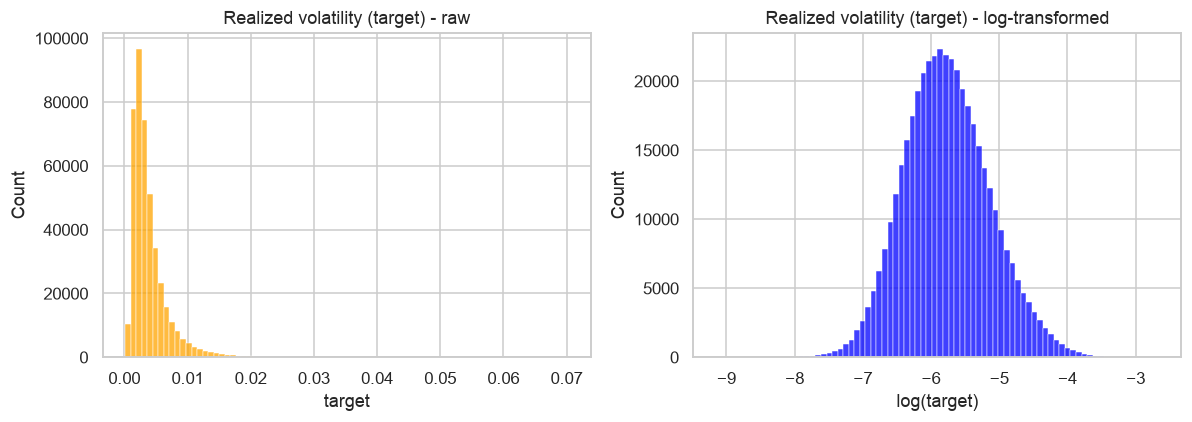

Skewness (raw): 2.8226009676256116
Skewness (log): 0.22303885675602117


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df["target"], bins=80, ax=axes[0], color="orange")
axes[0].set_title("Realized volatility (target) - raw")
axes[0].set_xlabel("target")

sns.histplot(np.log(df["target"]), bins=80, ax=axes[1], color="blue")
axes[1].set_title("Realized volatility (target) - log-transformed")
axes[1].set_xlabel("log(target)")

plt.tight_layout()
plt.show()

print("Skewness (raw):", df["target"].skew())
print("Skewness (log):", np.log(df["target"]).skew())

## 3. Feature distributions

Same skew question for the engineered features. This also matters for the **clustering**
task later: K-Means is distance-based, so if `trade_volume` ranges into the thousands
while `avg_spread_bps` ranges in single digits, the raw distance calculation would be
dominated by volume alone - features will need standardising before clustering if
their scales/skew differ this much.

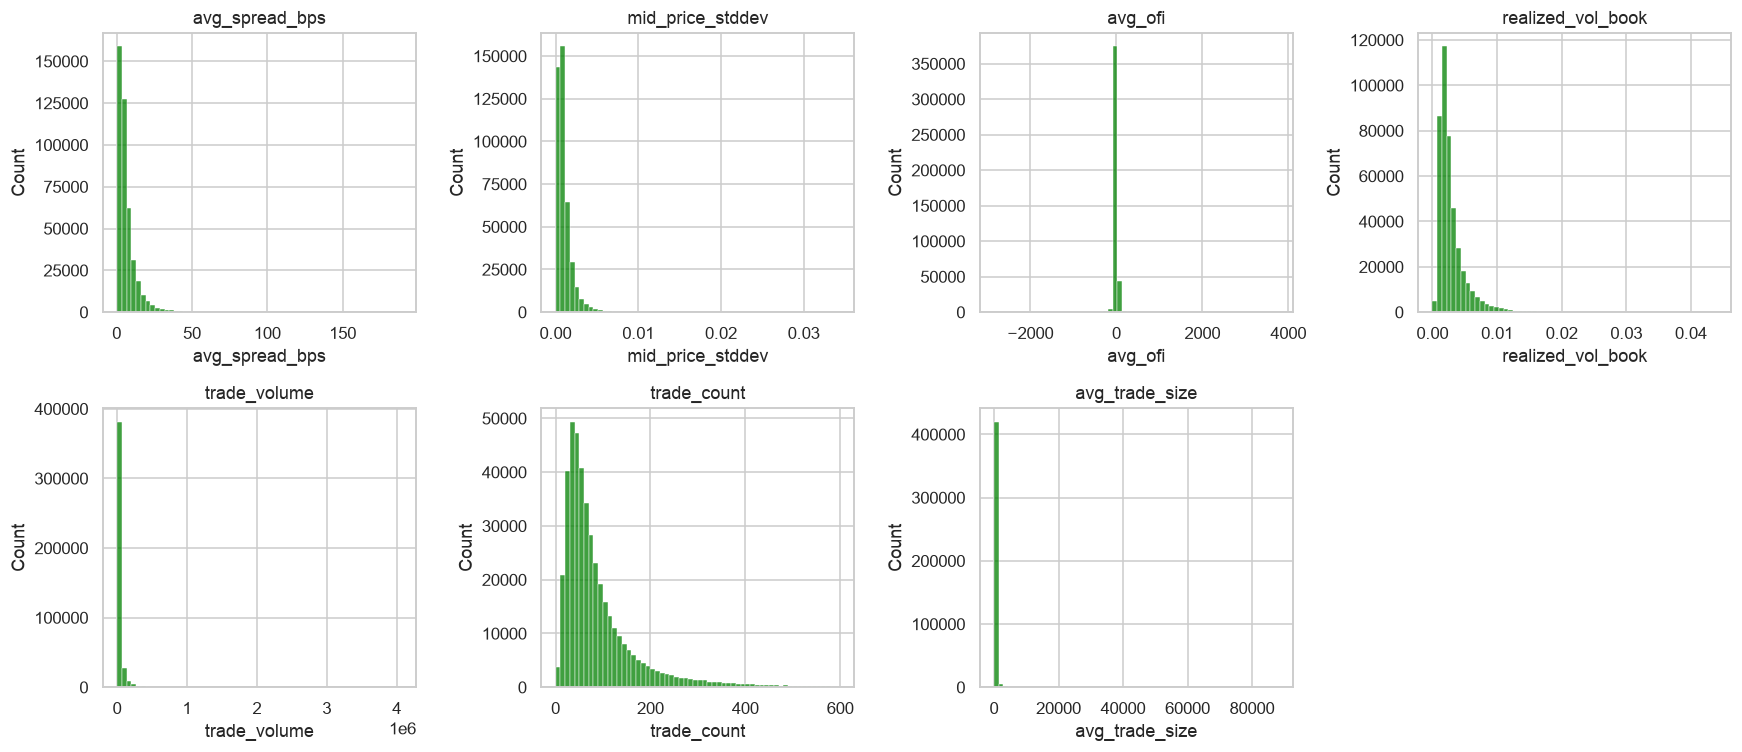

avg_trade_size       23.905409
trade_volume          9.206948
mid_price_stddev      4.495247
avg_spread_bps        3.998312
realized_vol_book     3.324100
trade_count           2.443304
avg_ofi               0.030932
dtype: float64

In [4]:
feature_cols = ["avg_spread_bps", "mid_price_stddev", "avg_ofi",
                "realized_vol_book", "trade_volume", "trade_count", "avg_trade_size"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, feature_cols):
    sns.histplot(df[col], bins=60, ax=ax, color="green")
    ax.set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

df[feature_cols].skew().sort_values(ascending=False)

## 4. Correlation with the target

Before spending time building models, check whether the engineered features actually
relate to the thing we're trying to predict. A feature with ~0 correlation to the
target isn't necessarily useless (relationships can be non-linear, which is exactly
what MLlib models beyond plain regression can pick up on) - but this is a fast,
honest first look at linear signal strength.

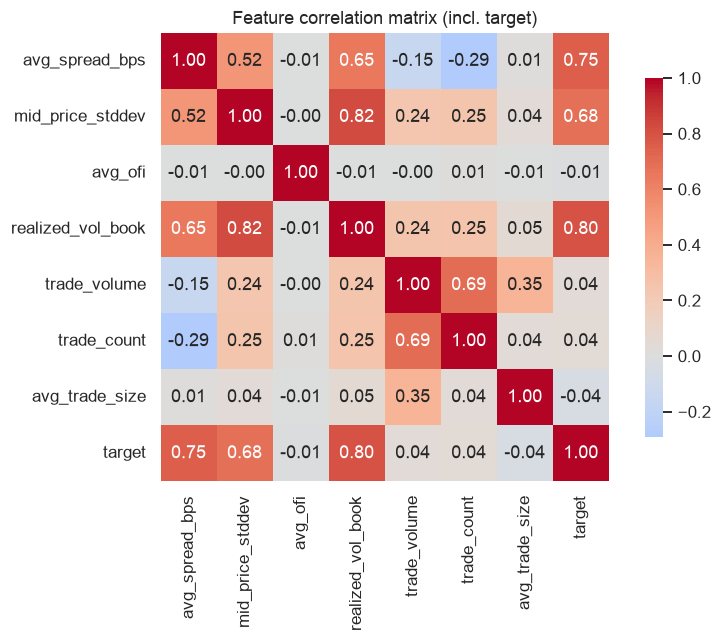

realized_vol_book    0.799052
avg_spread_bps       0.752852
mid_price_stddev     0.680294
trade_count          0.043752
avg_trade_size      -0.041517
trade_volume         0.036432
avg_ofi             -0.008770
Name: target, dtype: float64

In [5]:
corr_cols = feature_cols + ["target"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix (incl. target)")
plt.tight_layout()
plt.show()

corr["target"].drop("target").sort_values(key=abs, ascending=False)

## 5. Volatility clustering - does past volatility predict future volatility?

This is the single most important relationship for the regression task. `realized_vol_book`
is the volatility measured *within* the current 10-minute window; `target` is the
volatility of the *next* window. If turbulent windows tend to be followed by more
turbulent windows (and calm by calm), that's the well-known "volatility clustering"
stylized fact in finance - and it's the entire justification for why a volatility
forecasting model is expected to work at all.

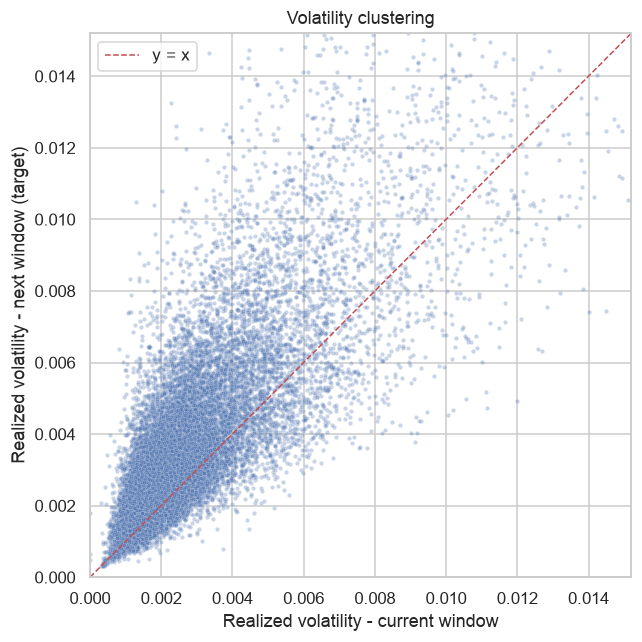

Correlation (current vs next window volatility): 0.7990519961066396


In [6]:
plt.figure(figsize=(6, 6))
sample = df.sample(n=min(20000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="realized_vol_book", y="target", s=8, alpha=0.3)
lims = [0, df[["realized_vol_book", "target"]].quantile(0.99).max()]
plt.plot(lims, lims, "r--", linewidth=1, label="y = x")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Realized volatility - current window")
plt.ylabel("Realized volatility - next window (target)")
plt.title("Volatility clustering")
plt.legend()
plt.tight_layout()
plt.show()

print("Correlation (current vs next window volatility):",
      df["realized_vol_book"].corr(df["target"]))

## 6. Per-stock variation

Different stocks have structurally different baseline volatility (a large stable
company behaves differently from a smaller, more volatile one). This matters for
the clustering task: if we cluster across all stocks without accounting for this,
K-Means may mostly just rediscover "which stock is this" rather than a genuine
cross-stock volatility *regime*.

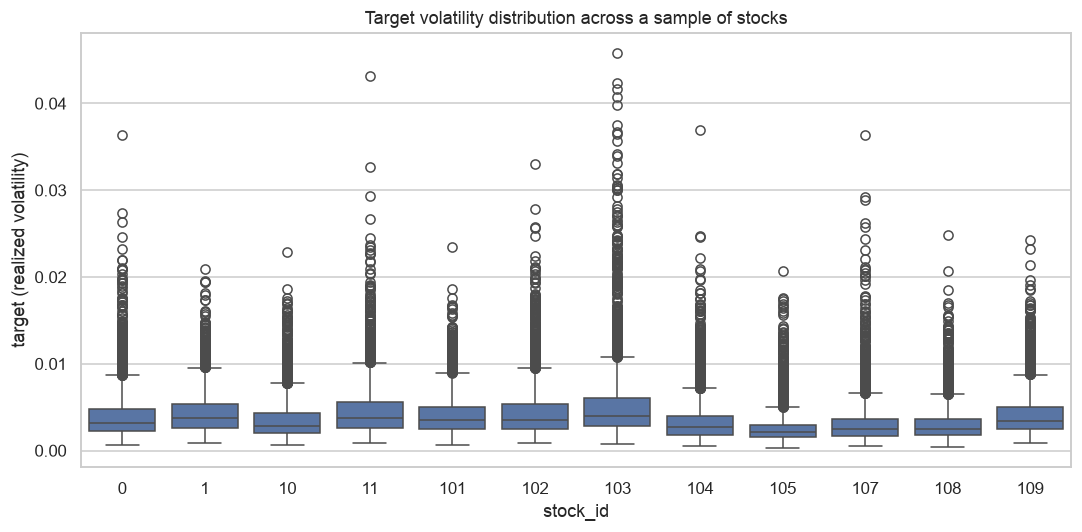

In [7]:
top_stocks = df["stock_id"].value_counts().head(12).index
subset = df[df["stock_id"].isin(top_stocks)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x="stock_id", y="target", order=sorted(top_stocks))
plt.title("Target volatility distribution across a sample of stocks")
plt.xlabel("stock_id")
plt.ylabel("target (realized volatility)")
plt.tight_layout()
plt.show()

## Takeaways for modeling

- **Target and several features are right-skewed** - log-transform candidates before
  linear regression; tree-based / Spark MLlib regressors are less sensitive to this
  but it's still worth checking residuals later.
- **Volatility clustering is present** (current-window volatility correlates with
  next-window volatility) - confirms the regression task has real signal to learn,
  not just noise.
- **Feature scales vary widely** - standardise features before K-Means clustering.
- **Stocks differ structurally in baseline volatility** - worth considering whether
  to cluster on relative/normalised volatility rather than raw values, so clusters
  reflect *regimes* rather than *which stock it is*.